In [ ]:
import numpy as np
import pandas as pd
df=pd.read_csv('../data/player.csv')
df.head(2)

,player_api_id,player_name,birthday,height,weight
0,505942,Aaron Appindangoye,1992-02-29 00:00:00,182.88,187
1,155782,Aaron Cresswell,1989-12-15 00:00:00,170.18,146


In [2]:
# 按照birth分组后实现身高和体重的均值聚合
df['birth']=np.select([df.height>=185,\
    (df.height>=165)&(df.height<185)],[2,1],0)
df.set_index(['birth'],append=True,inplace=True)
df.head(2)

,,player_api_id,player_name,birthday,height,weight
,birth,,,,,
0,1,505942,Aaron Appindangoye,1992-02-29 00:00:00,182.88,187
1,1,155782,Aaron Cresswell,1989-12-15 00:00:00,170.18,146


In [3]:
# 实现分组后身高列的均值聚合
# 实现分组后体重列的均值聚合
df.groupby('birth')['height'].mean()
df.groupby('birth')['weight'].mean()

birth
0    161.713333
1    178.176441
2    188.651430
Name: height, dtype: float64

birth
0    133.416667
1    161.647364
2    180.749745
Name: weight, dtype: float64

In [5]:
# 按birth分组后取值为0的分组数据
# 获取按birth分组后取值为1的分组数据信息描述
df.groupby("birth").get_group(0)
df.groupby("birth").get_group(1).describe()
df.dtypes

,,player_api_id,player_name,birthday,height,weight
,birth,,,,,
829,0,11327,Anthony Deroin,1979-03-15 00:00:00,162.56,146
1081,0,30691,Bakari Kone,1981-09-17 00:00:00,162.56,134
2609,0,103139,Diego Buonanotte,1988-04-19 00:00:00,160.02,123
2853,0,278917,Edgar Salli,1992-08-17 00:00:00,162.56,141
3442,0,215412,Fouad Rachid,1991-11-15 00:00:00,162.56,126
3580,0,143752,Frederic Sammaritano,1986-03-23 00:00:00,162.56,146
5446,0,97226,Juan Quero,1984-10-17 00:00:00,157.48,117
6205,0,193441,Lorenzo Insigne,1991-06-04 00:00:00,162.56,130
7247,0,29587,Maxi Moralez,1987-02-27 00:00:00,160.02,126


,player_api_id,height,weight
count,7132.000000,7132.000000,7132.000000
mean,161753.235418,178.176441,161.647364
std,164502.113730,4.191669,11.791783
min,2625.000000,165.100000,121.000000
25%,36143.500000,175.260000,154.000000
50%,100537.000000,177.800000,161.000000
75%,215784.500000,182.880000,170.000000
max,750584.000000,182.880000,212.000000


player_api_id      int64
player_name       object
birthday          object
height           float64
weight             int64
dtype: object

In [6]:
# 按照birthday列进行分组
# 分组后实现体重列的均值聚合以及按索引的排序操作
df.groupby(by='birthday')['weight'].mean()
df.groupby(by='birthday')['weight'].mean().sort_index()

birthday
1967-01-23 00:00:00    161.0
1968-06-26 00:00:00    187.0
1969-01-15 00:00:00    183.0
1969-03-13 00:00:00    174.0
1969-04-01 00:00:00    183.0
                       ...  
1998-12-16 00:00:00    157.0
1998-12-20 00:00:00    148.0
1999-01-23 00:00:00    170.0
1999-02-25 00:00:00    198.0
1999-04-24 00:00:00    141.0
Name: weight, Length: 5762, dtype: float64

birthday
1967-01-23 00:00:00    161.0
1968-06-26 00:00:00    187.0
1969-01-15 00:00:00    183.0
1969-03-13 00:00:00    174.0
1969-04-01 00:00:00    183.0
                       ...  
1998-12-16 00:00:00    157.0
1998-12-20 00:00:00    148.0
1999-01-23 00:00:00    170.0
1999-02-25 00:00:00    198.0
1999-04-24 00:00:00    141.0
Name: weight, Length: 5762, dtype: float64

<Axes: xlabel='birth_year'>

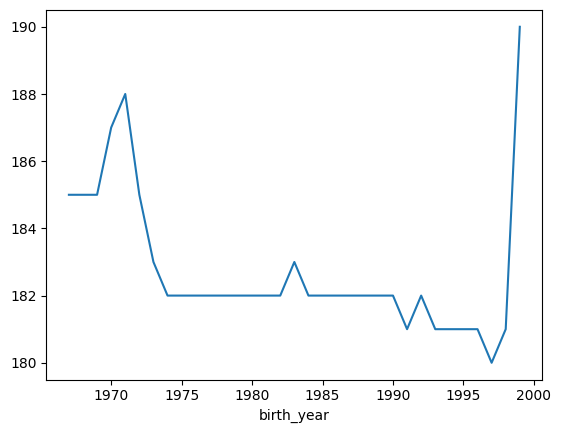

In [7]:
# 不同年出生球员平均身高变化趋势
df=pd.read_csv('../data/player.csv')
df['birth_year']=pd.to_datetime(df.birthday).dt.year
df_clean = df.dropna(subset=['birth_year', 'height']).copy()
h= df_clean.groupby('birth_year')['height'].mean().round(0).sort_index()
h.plot(x='birth_year',y='height')

<Axes: xlabel='season'>

c:\ai\Anaconda\envs\a1\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ai\Anaconda\envs\a1\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ai\Anaconda\envs\a1\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\ai\Anaconda\envs\a1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ai\Anaconda\envs\a1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ai\Anaconda\envs\a1\Lib\site-pa

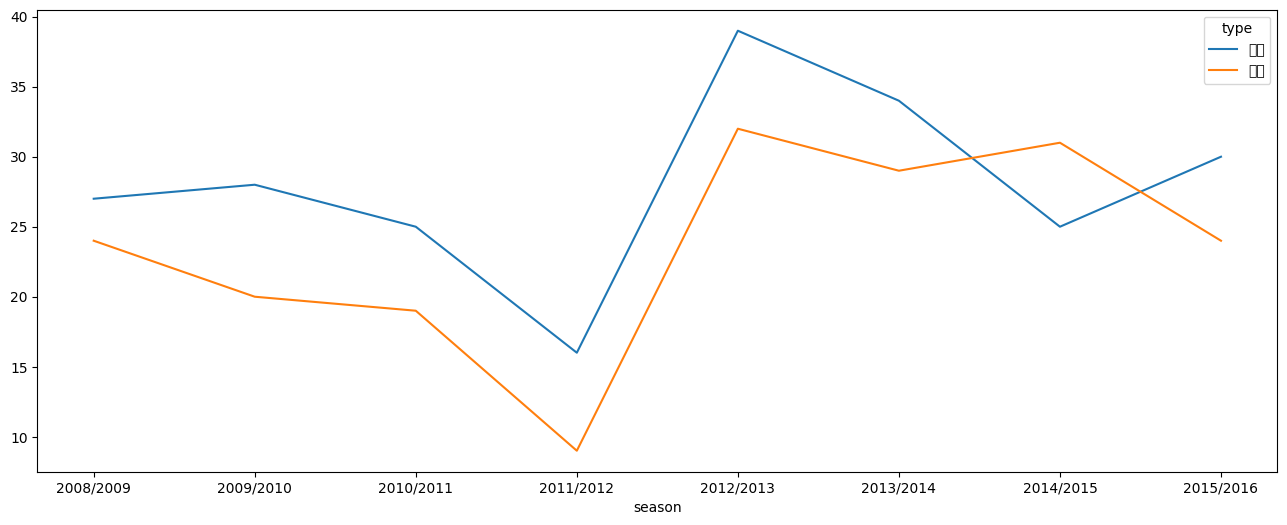

In [8]:
# 佛罗伦萨队(8535)，各赛季作为主队、客队进球的总情况
df=pd.read_csv('../data/match.csv')
home=df.loc[df.home_team_api_id==8535,['season','home_team_goal']]
home = home.rename(columns={'home_team_goal': 'goals'})
home['type'] = '主场'
away=df.loc[df.away_team_api_id==8535,['season','away_team_goal']]
away = away.rename(columns={'away_team_goal': 'goals'}) 
away['type'] = '客场' 
c=pd.concat([home,away])
d=c.groupby(['season', 'type'])['goals'].sum().unstack()
d.plot(rot=0,figsize=(16,6))

<Axes: xlabel='season'>

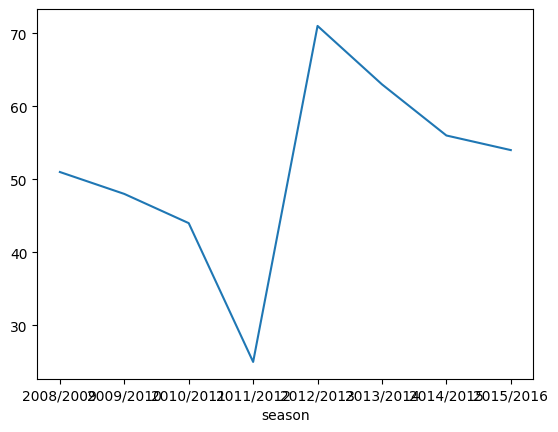

In [9]:
# 佛罗伦萨队(8535)，各赛季总情况
df=pd.read_csv('../data/match_goal.csv')
f=df[df['team_api_id'] == 8535].groupby('season')['team_goal'].sum().sort_index()
f.plot()

,id,league_id,season,stage,match_api_id,local,team_api_id,team_goal
0,0,1,2008/2009,24,493017,away,9987,1
1,1,1,2008/2009,24,493017,home,8203,2


<Axes: xlabel='season'>

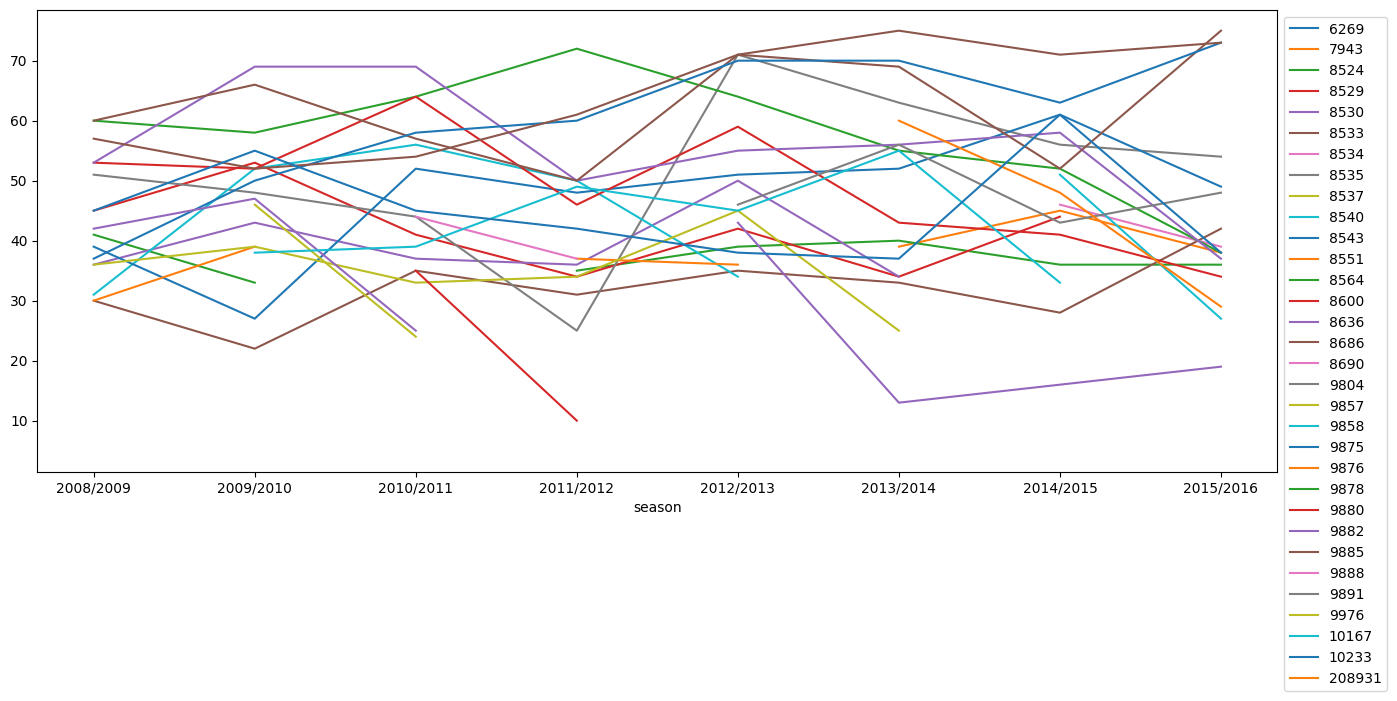

In [10]:
# 意甲联赛(10257)各队赛季总进球变化趋势
df=pd.read_csv('../data/match_goal.csv')
df.head(2)
team=df [df ['league_id'] == 10257].groupby(['season','team_api_id']).team_goal.sum().unstack()
team.plot(figsize=(16,6))
from matplotlib import pyplot as plt
plt.legend(bbox_to_anchor=(1,1))